# Visualizations

## Imports

In [1]:
%run curtis.ipynb

Processing standard ACS datasets...
Successfully processed and saved rent_clean.csv
Successfully processed and saved home_value_clean.csv
Successfully processed and saved rent_burden_clean.csv
Processing Housing Age dataset...
Successfully processed and saved housing_age_clean.csv
Successfully processed and saved housing_age_clean.csv
Processing Poverty dataset...
Successfully processed and saved poverty_rate_clean.csv
Processing Income dataset...
Successfully processed and saved income_clean.csv
Processing Active Permits dataset...
Successfully processed and saved permits_2024_clean.csv
All files processed successfully!
Processing Neighborhood GeoDataFrame...
Successfully processed
Processing Permit GeoDataFrame...
Successfully processed and saved permits_neighborhoods_clean.csv
Processing Tracts GeoDataFrame...
Successfully processed and saved permits_tracts_clean.csv
Processing Zip Code GeoDataFrame...
Successfully processed and saved zip_codes_clean.csv
Merging all DataFrames...
Su

In [2]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import matplotlib.ticker as mticker
# convert seaborn graph to plt
import seaborn as sns
from pypalettes import load_cmap
from highlight_text import ax_text
from drawarrow import ax_arrow
from cycler import cycler

# sets the float format for pandas to display numbers without decimal places
pd.set_option('display.float_format', '{:,.0f}'.format)

## Style Settings

In [3]:
# Define your custom colors
colors = ['#FEBE10', '#1D1E9E', '#AD0000', '#000000', '#FFFFFF']

plt.rcParams.update({
    # Colors
    'axes.prop_cycle': cycler('color', colors),

    # Background
    'figure.facecolor': 'lightgrey',
    'axes.facecolor': 'lightgrey',
    'savefig.facecolor': 'lightgrey',

    # Grid
    'axes.grid': True,
    'grid.color': '#000000',
    'grid.alpha': 0.1,
    'grid.linestyle': '--',

    # Lines & markers
    'lines.linewidth': 2,
    'lines.markersize': 6,
    'lines.markeredgewidth': 0.5,

    # Axes & ticks
    'axes.edgecolor': '#000000',
    'axes.labelcolor': '#000000',
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.color': '#000000',
    'ytick.color': '#000000',
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,

    # Legend
    'legend.frameon': False,
    'legend.fontsize': 10,
    'legend.loc': 'best',

    # Font
    'font.family': 'DejaVu Sans',
    'text.color': '#000000',

    # Savefig
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})


## Function for Formatting Numbers

In [4]:
# Create the formatter once
formatter = mticker.StrMethodFormatter("{x:,.0f}")

def apply_formatter(ax=None):
    """Automatically format numeric axes with commas, leave text/categorical axes alone."""
    if ax is None:
        ax = plt.gca()
    
    # Format x-axis only if tick labels are numbers
    x_labels = [lbl.get_text() for lbl in ax.get_xticklabels()]
    if all(_is_number(lbl) for lbl in x_labels):
        ax.xaxis.set_major_formatter(formatter)
    
    # Format y-axis only if tick labels are numbers
    y_labels = [lbl.get_text() for lbl in ax.get_yticklabels()]
    if all(_is_number(lbl) for lbl in y_labels):
        ax.yaxis.set_major_formatter(formatter)

def _is_number(s):
    """Helper to check if string can be converted to float."""
    try:
        float(s.replace(',', ''))  # remove commas if already formatted
        return True
    except ValueError:
        return False

## Choropleths

In [5]:
# Geometry = polygon
map_df = gdf_tracts.merge(df_plot, on = "GEOID", how = "left")

map_df.to_csv(PROCESSED_DIR / 'map.csv', index=False)

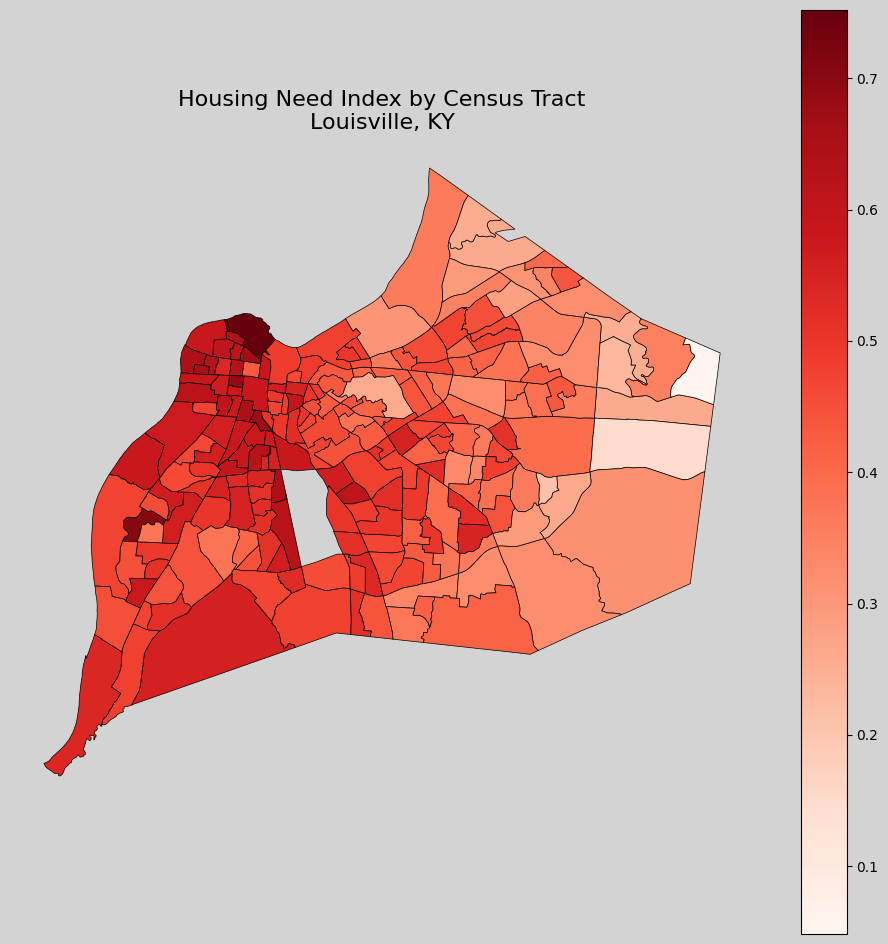

In [6]:
# Housing Need Choropleth (no labels)
fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

ax.set_title("Housing Need Index by Census Tract\nLouisville, KY", fontsize=16)

ax.axis("off")

plt.savefig(FIGURES_DIR / "need_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

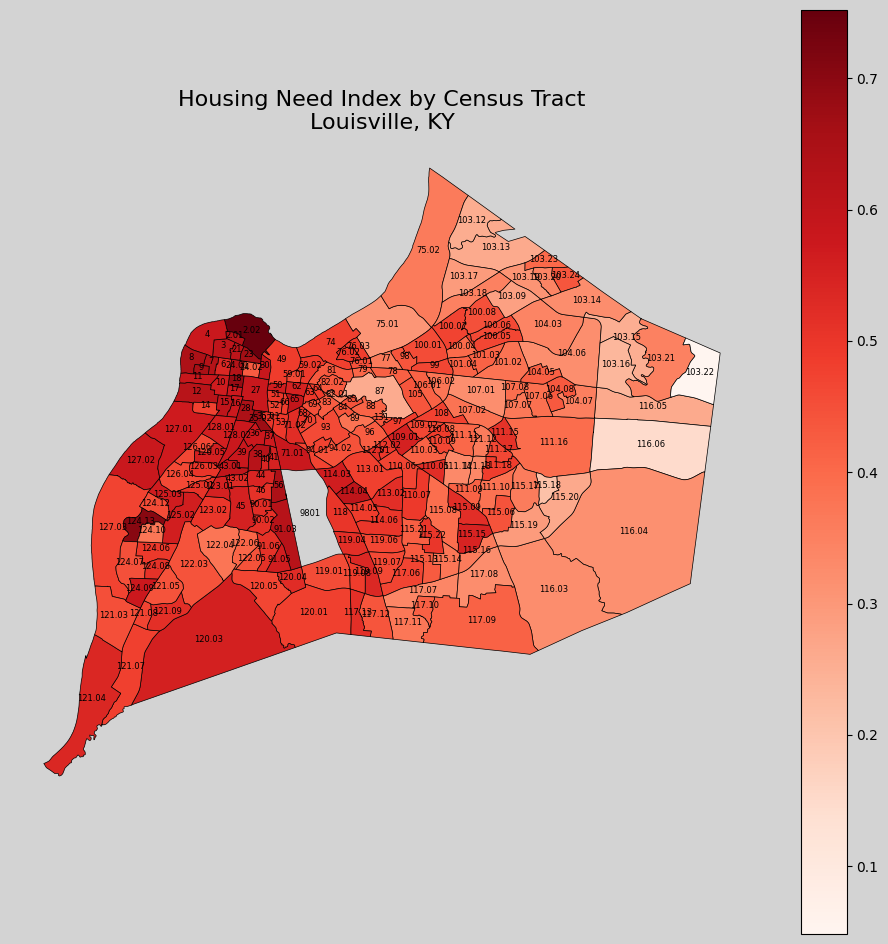

In [ ]:
# Housing Need Choropleth (Tract Labeled)

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Add tract labels
for idx, row in map_df.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["TRACT"],
        fontsize=6,
        ha="center"
    )

ax.set_title(
    "Housing Need Index by Census Tract\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "need_choropleth_with_tract_labels.png", dpi=300, bbox_inches="tight")

plt.show()

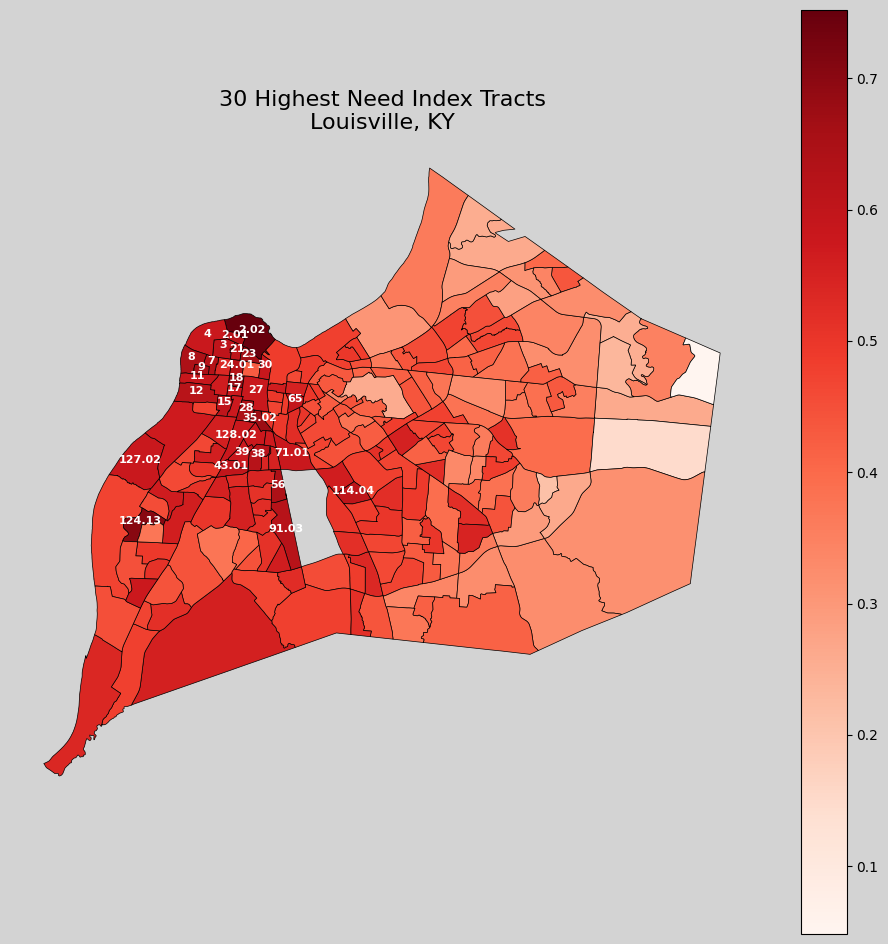

In [8]:
# Highest Housing Need Choropleth 

top_tracts = map_df.nlargest(30, "NEED_INDEX")

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in top_tracts.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["TRACT"],
        fontsize=8,
        fontweight="bold",
        color='white',
        ha="center"
    )

ax.set_title("30 Highest Need Index Tracts\nLouisville, KY", fontsize=16)
ax.axis("off")

plt.savefig(FIGURES_DIR / "highest_need_choropleth_with_labels.png", dpi=300, bbox_inches="tight")
plt.show()

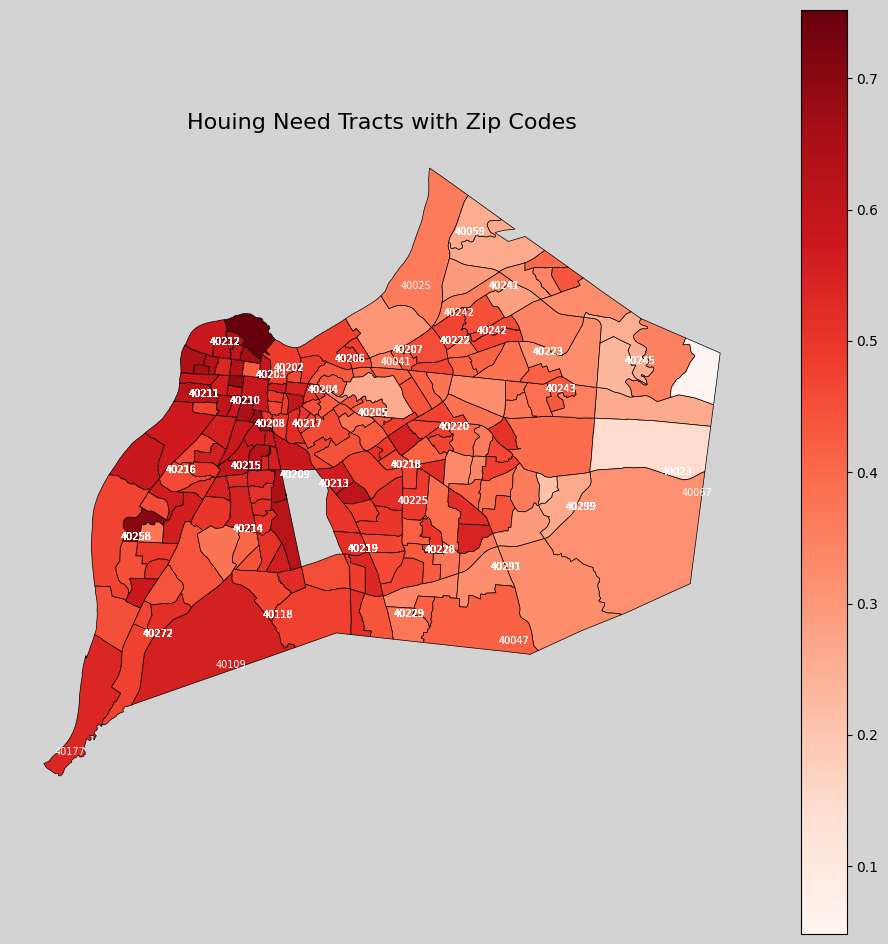

In [9]:
# Housing Need Choropleth with Zip Codes

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in gdf_zip_code_tracts.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["ZIPCODE"],
        fontsize=7,
        fontweight="normal",
        color='white',
        ha="center"
    )

ax.set_title("Houing Need Tracts with Zip Codes", fontsize=16)

ax.axis("off")

plt.savefig(FIGURES_DIR / "highest_need_choropleth_with_zip_codes.png", dpi=300, bbox_inches="tight")

plt.show()

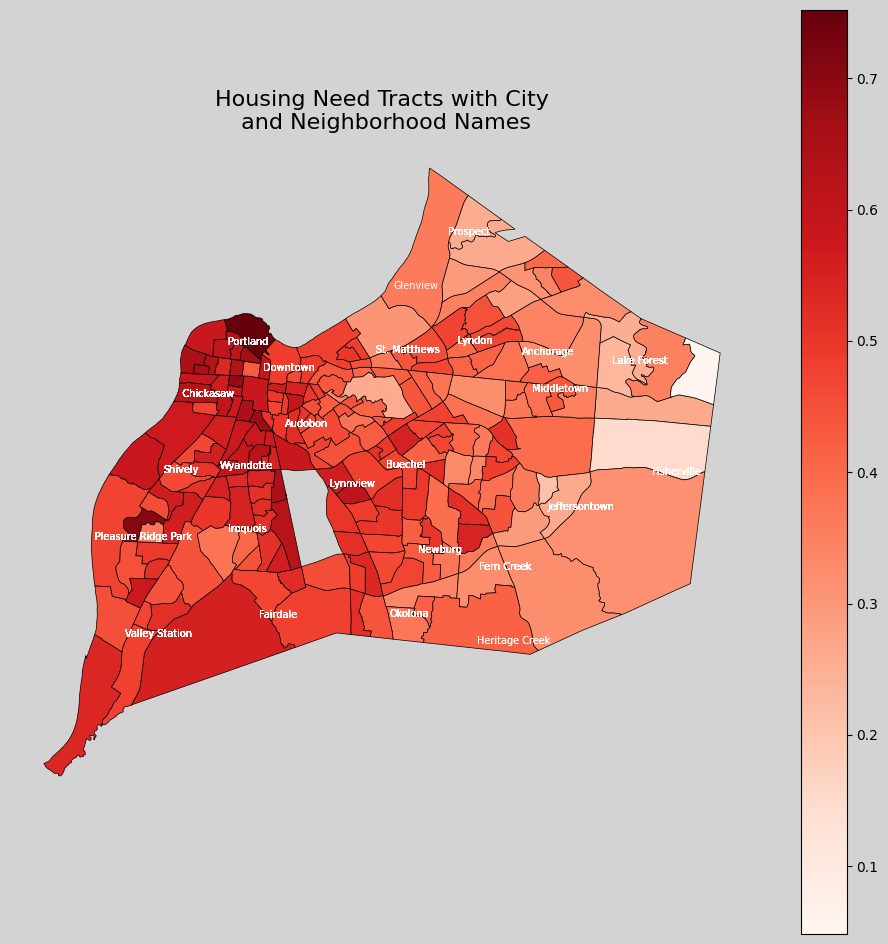

In [10]:
# Housing Need Choropleth with Zip Codes

fig, ax = plt.subplots(figsize=(12, 12))

# Plot tract polygons colored by NEED_INDEX
map_df.plot(
    column="NEED_INDEX",
    cmap="Reds",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

gdf_zip_code_tracts_filtered = gdf_zip_code_tracts[
    (gdf_zip_code_tracts["CITY"] != "Louisville") &
    (gdf_zip_code_tracts["CITY"].notna())
]

for idx, row in gdf_zip_code_tracts_filtered.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["CITY"],
        fontsize=7,
        fontweight="300",
        color='white',
        ha="center"
    )

ax.set_title(
    "Housing Need Tracts with City\n and Neighborhood Names",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "need_choropleth_with_neighborhood_labels.png", dpi=300, bbox_inches="tight")

plt.show()

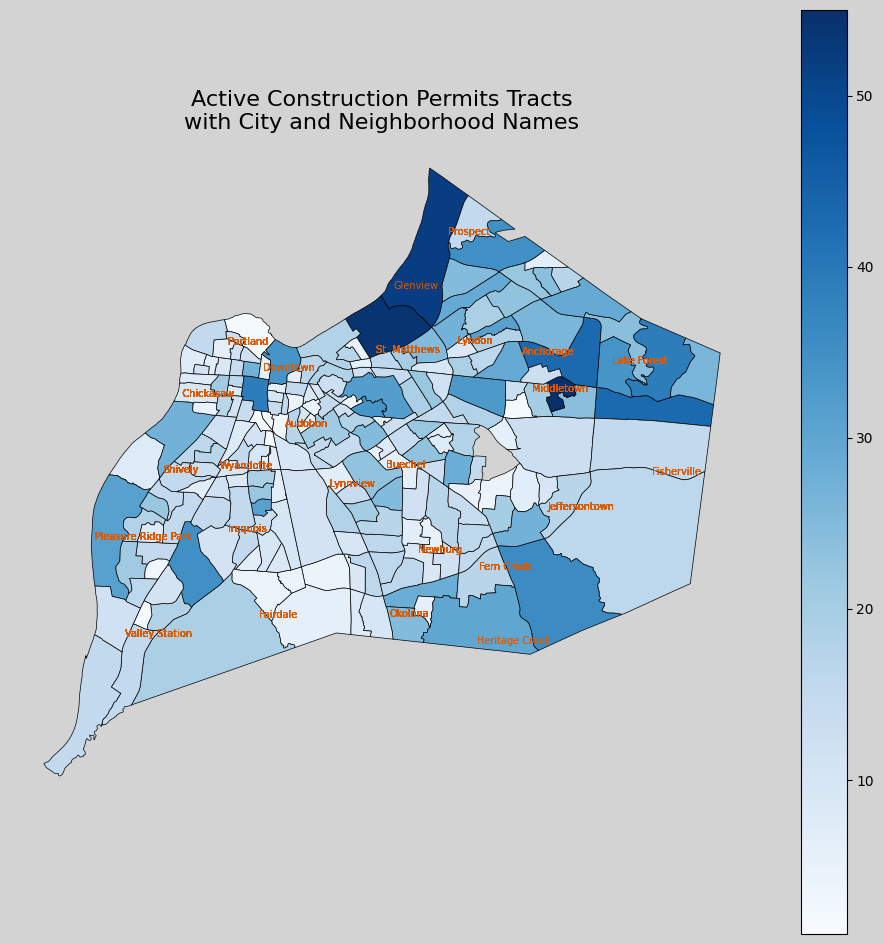

In [11]:
# Permit Choropleth

fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="PERMIT_COUNT",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

# Neighborhood/City Labels
for idx, row in gdf_zip_code_tracts_filtered.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["CITY"],
        fontsize=7,
        fontweight="300",
        color= '#DD5A02',
        ha="center"
    )

ax.set_title(
    "Active Construction Permits Tracts\nwith City and Neighborhood Names",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "permit_count_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

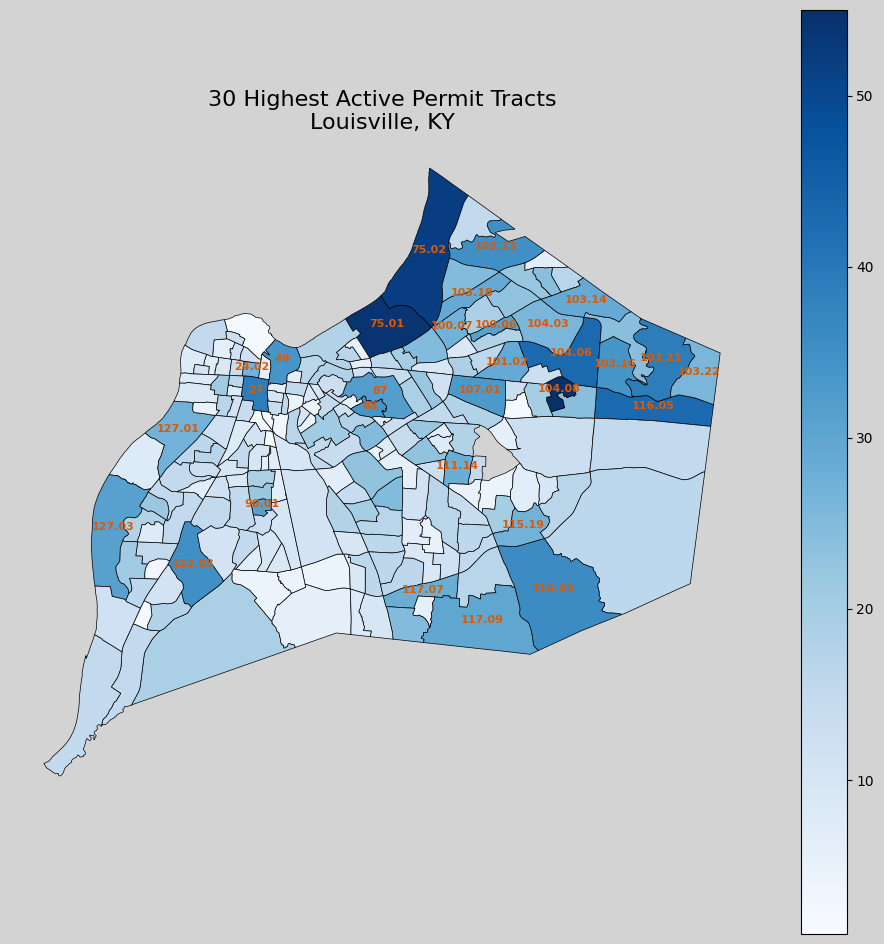

In [12]:
# Permit Choropleth

top_permit_tracts = map_df.nlargest(30, "PERMIT_COUNT")

fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="PERMIT_COUNT",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in top_permit_tracts.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["TRACT"],
        fontsize=8,
        fontweight="bold",
        color='#DD5A02',
        ha="center"
    )

ax.set_title(
    "30 Highest Active Permit Tracts\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "highest_permits_by_tract_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

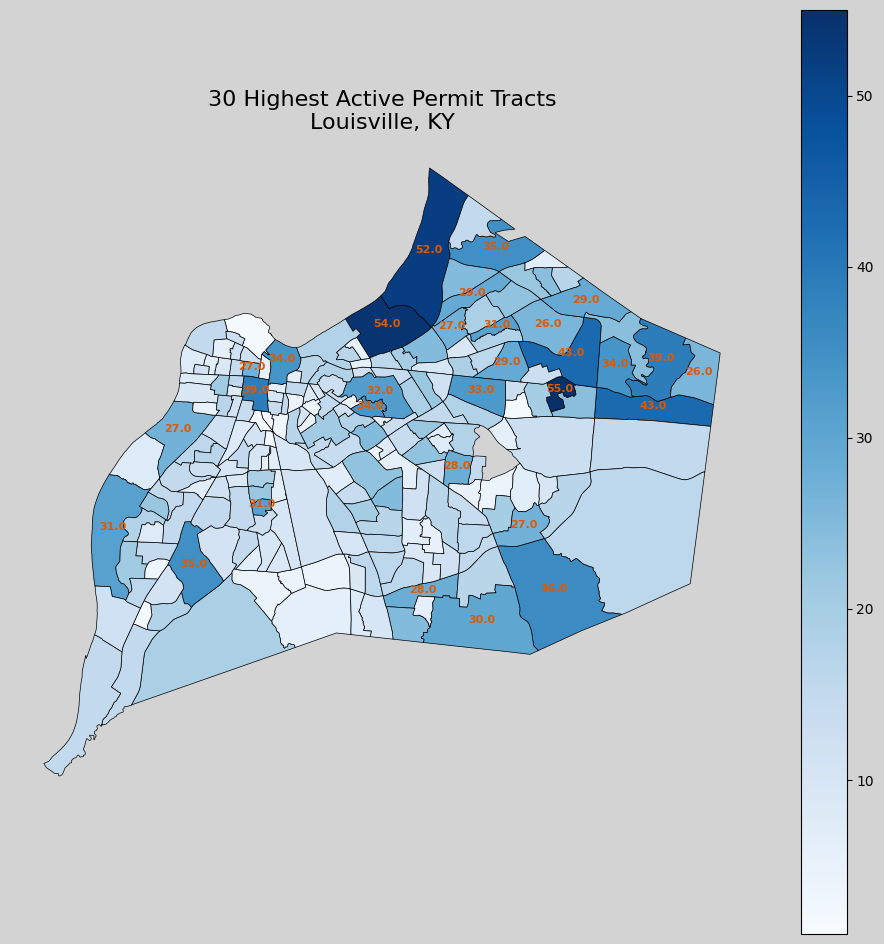

In [13]:
# Permit Choropleth

top_permit_count = map_df.nlargest(30, "PERMIT_COUNT")

fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="PERMIT_COUNT",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in top_permit_count.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        row["PERMIT_COUNT"],
        fontsize=8,
        fontweight="bold",
        color='#DD5A02',
        ha="center"
    )

ax.set_title(
    "30 Highest Active Permit Tracts\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "highest_permits_by_count_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

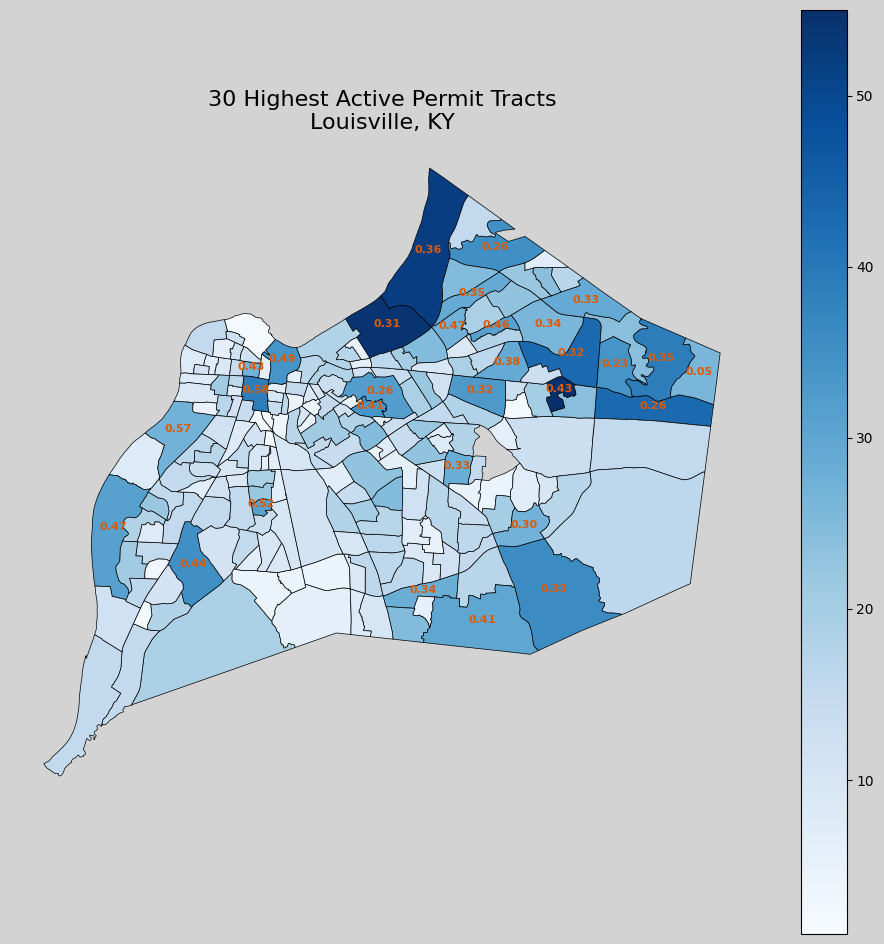

In [14]:
# Permit Choropleth

top_permit_need = map_df.nlargest(30, "PERMIT_COUNT")

fig, ax = plt.subplots(figsize=(12, 12))

map_df.plot(
    column="PERMIT_COUNT",
    cmap="Blues",
    linewidth=0.5,
    edgecolor="black",
    legend=True,
    ax=ax
)

for idx, row in top_permit_need.iterrows():
    centroid = row.geometry.centroid

    ax.text(
        centroid.x,
        centroid.y,
        f"{row['NEED_INDEX']:.2f}",
        fontsize=8,
        fontweight="bold",
        color='#DD5A02',
        ha="center"
    )

ax.set_title(
    "30 Highest Active Permit Tracts\nLouisville, KY",
    fontsize=16
)

ax.axis("off")

plt.savefig(FIGURES_DIR / "highest_permits_by_need_choropleth.png", dpi=300, bbox_inches="tight")

plt.show()

# Charts

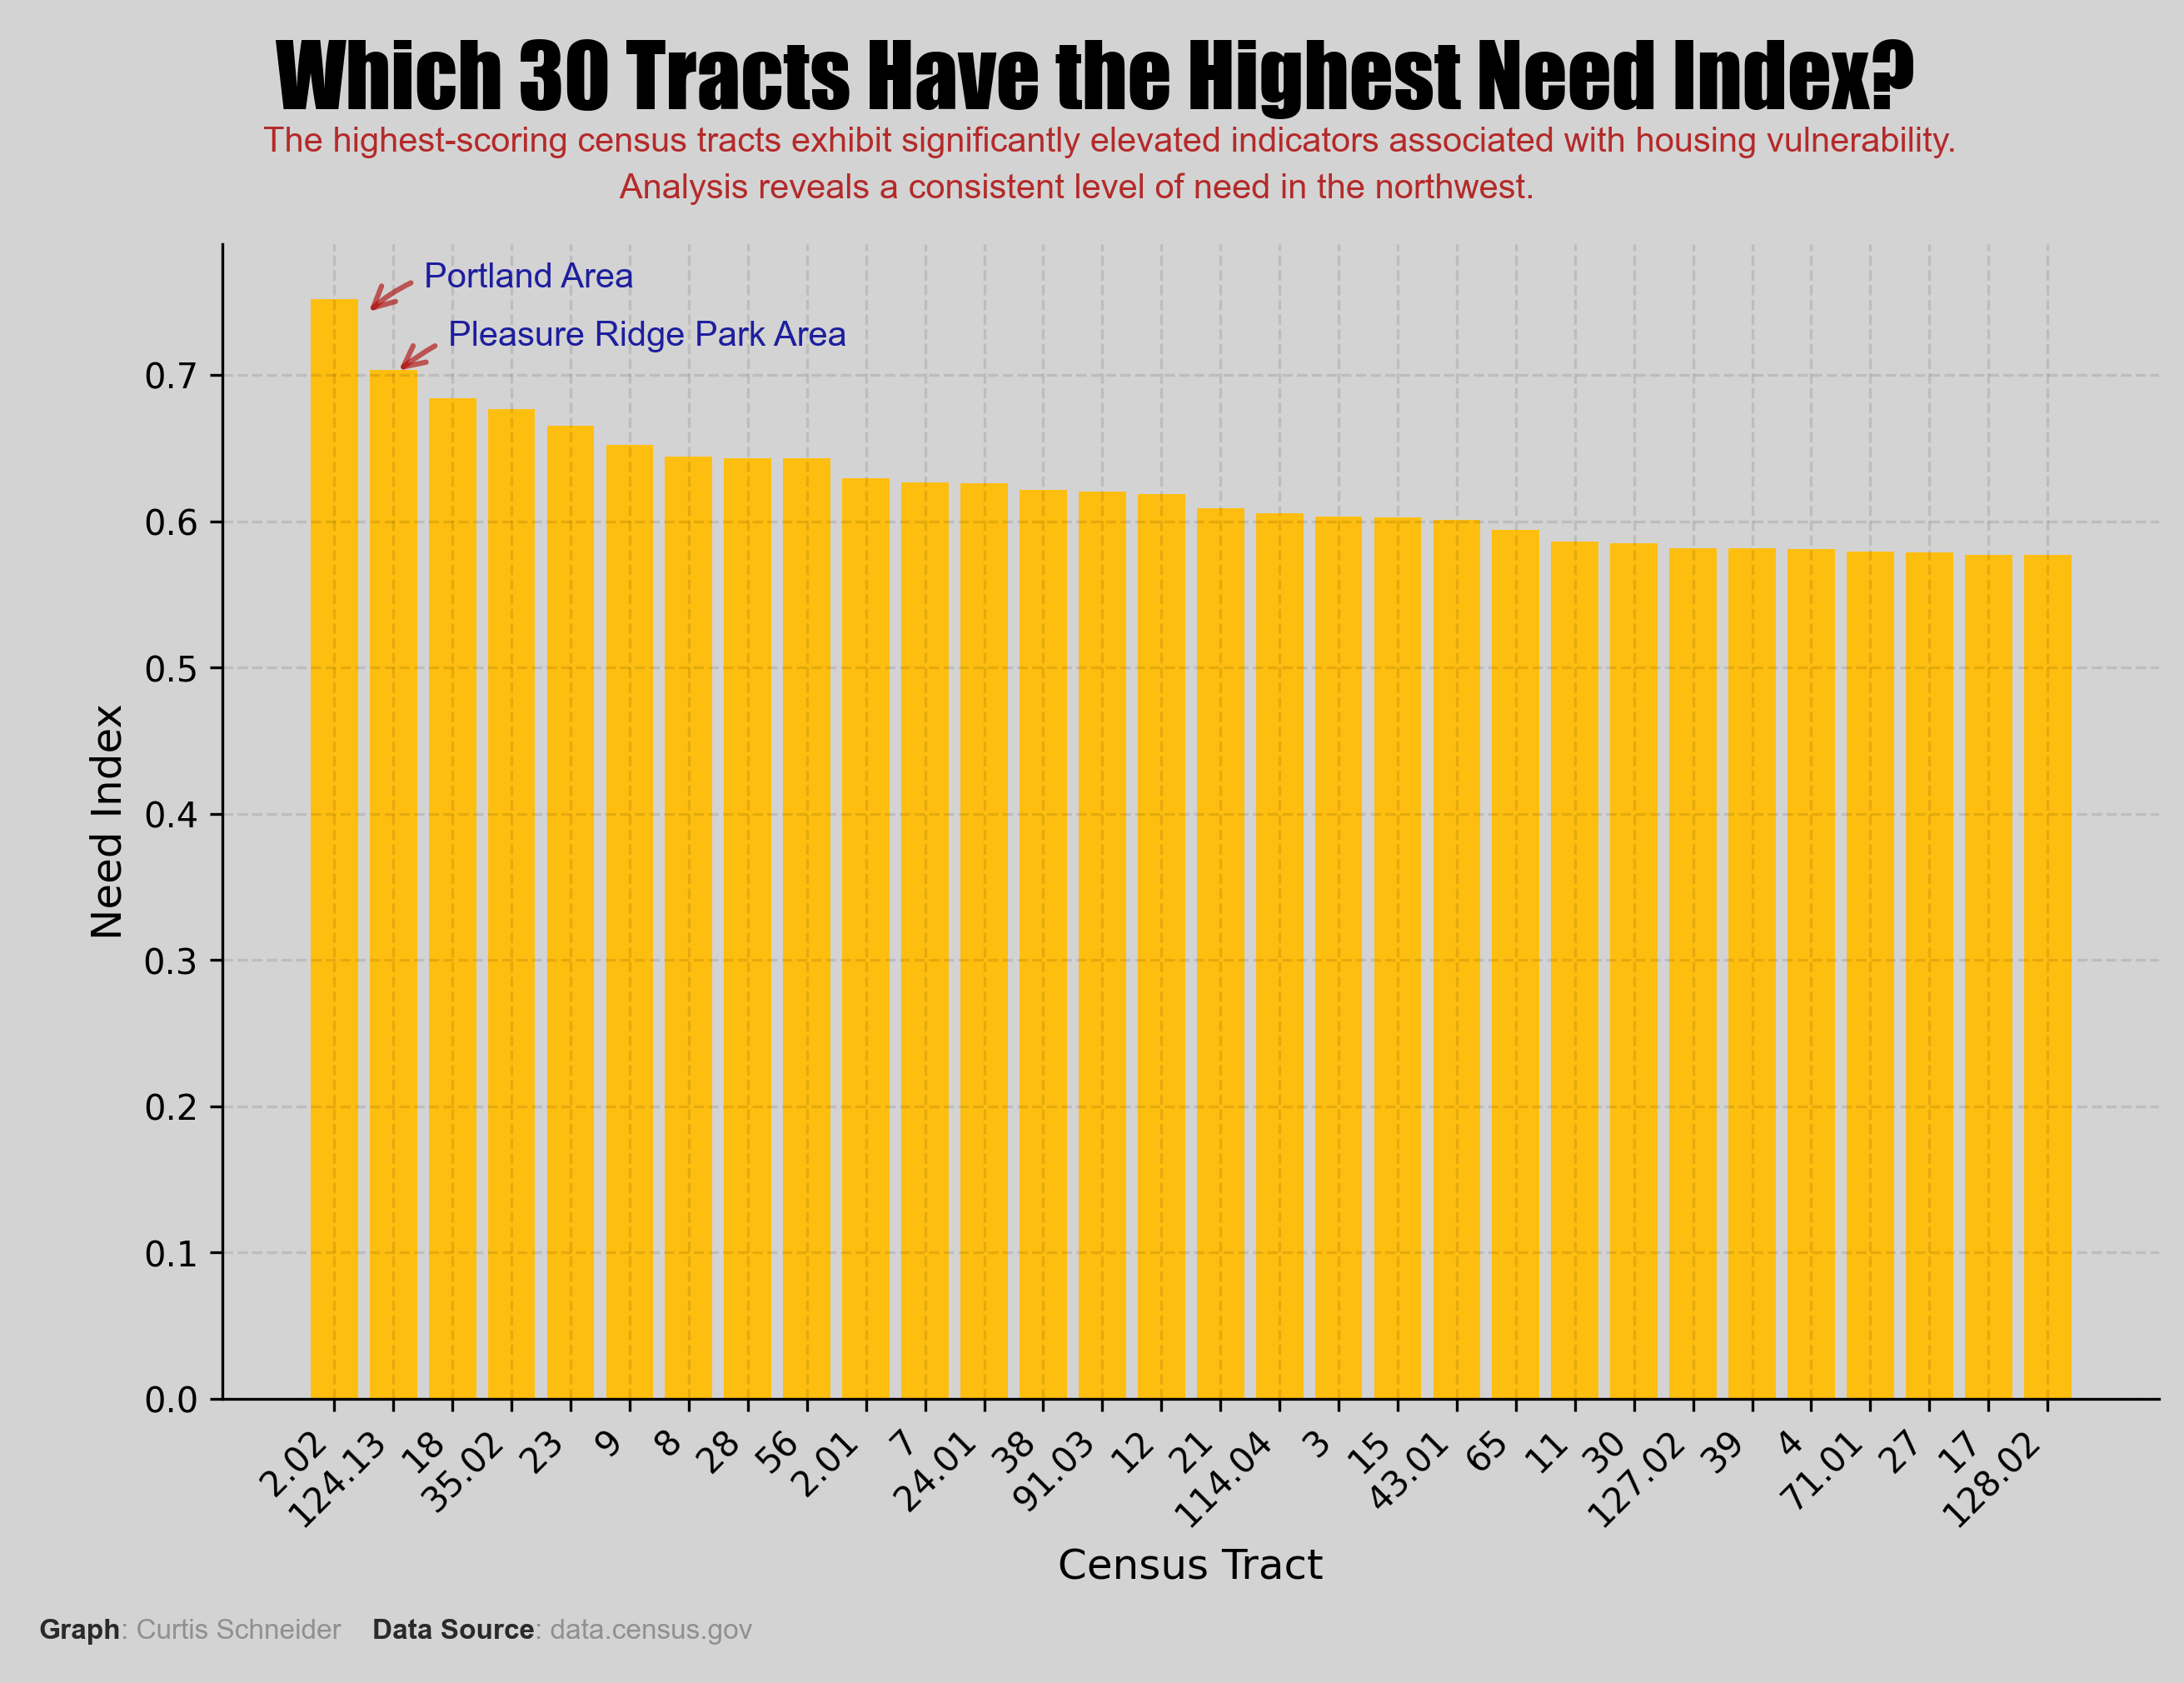

In [15]:
top_tracts = (
    map_df[['TRACT', 'NEED_INDEX']]
    .sort_values(by='NEED_INDEX', ascending=False)
    .head(30)
)

plt.figure(figsize=(10,6), dpi = 300)
ax = plt.gca()

# Plot type
plt.bar(top_tracts['TRACT'].astype(str), top_tracts['NEED_INDEX'])

# Labels
plt.xlabel('Census Tract')
plt.ylabel('Need Index')
plt.xticks(rotation=45, ha ="right")

# Title (added space for larger figure)
s = "Which 30 Tracts Have the Highest Need Index?"
ax_text(x=-1, y=.93, s=s, fontfamily='impact', size=25, ha="left")

# Additional subtitle
s = "The highest-scoring census tracts exhibit significantly elevated indicators associated with housing vulnerability.\n" \
"                                     Analysis reveals a consistent level of need in the northwest."
ax_text(x=-1.2, y=0.87, s=s, fontfamily='arial', size=10, ha="left", color="#AD0000", alpha=0.8)

# Annotation arrow
ax.annotate(
    "Portland Area",
    xy=(.5, 0.74),
    xytext=(3.3, 0.76),
    ha="center",
    fontsize=10,
    fontfamily='Arial',
    color="#1D1E9E",
    # alpha=0.8,
    arrowprops=dict(
        arrowstyle="->",
        color="#AD0000",
        lw=1.5,
        mutation_scale=15,
        connectionstyle="arc3,rad=0.3",
        alpha=0.6,
    )
)

# Annotation arrow
ax.annotate(
    "Pleasure Ridge Park Area",
    xy=(1, 0.70),
    xytext=(5.3, 0.72),
    ha="center",
    fontsize=10,
    fontfamily='Arial',
    color="#1D1E9E",
    # alpha=0.8,
    arrowprops=dict(
        arrowstyle="->",
        color="#AD0000",
        lw=1.5,
        mutation_scale=15,
        connectionstyle="arc3,rad=0.3",
        alpha=0.6,
    )
)

# Caption
s = "<Graph>: Curtis Schneider    <Data Source>: data.census.gov"
ax_text(
    x=-5,
    y=-.15,
    s=s,
    fontfamily='Arial',
    size=8,
    color='grey',
    ha="left",
    alpha=0.8,
    highlight_textprops=[
        {"weight": "bold", "color": "black"},
        {"weight": "bold", "color": "black"}
    ]
)

plt.savefig(FIGURES_DIR / "highest_need_bar_chart.png", bbox_inches="tight")

plt.show()

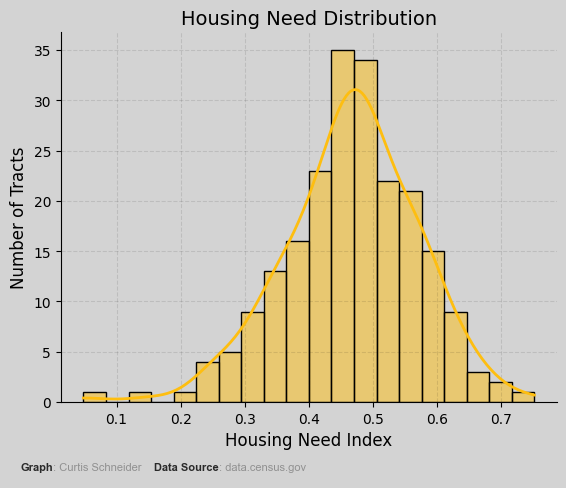

In [16]:
# Histogram showing number of tracts vs their need count
sns.histplot(
    map_df['NEED_INDEX'],
    bins=20,
    kde=True
)

plt.xlabel("Housing Need Index")
plt.ylabel("Number of Tracts")
plt.title("Housing Need Distribution")

# Caption
s = "<Graph>: Curtis Schneider    <Data Source>: data.census.gov"
ax_text(
    x=-.05,
    y=-6,
    s=s,
    fontfamily='Arial',
    size=8,
    color='grey',
    ha="left",
    alpha=0.8,
    highlight_textprops=[
        {"weight": "bold", "color": "black"},
        {"weight": "bold", "color": "black"}
    ]
)

plt.savefig(FIGURES_DIR / "housing_need_bar_chart.png", bbox_inches="tight")

plt.show()

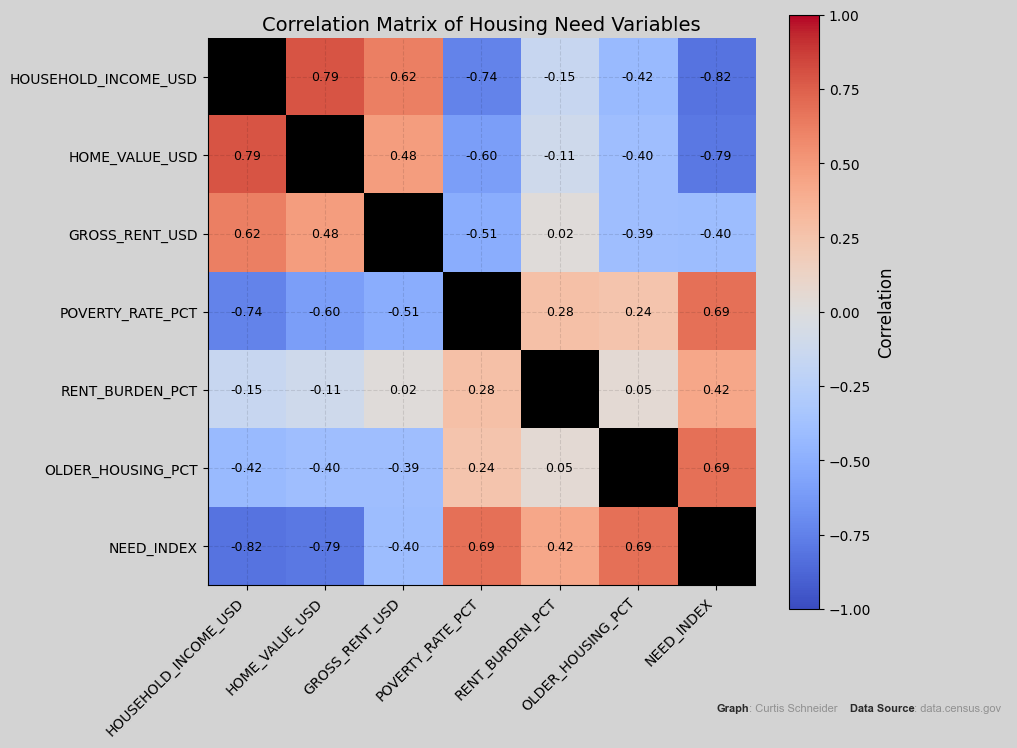

In [17]:
corr_cols = [
    'HOUSEHOLD_INCOME_USD',
    'HOME_VALUE_USD',
    'GROSS_RENT_USD',
    'POVERTY_RATE_PCT',
    'RENT_BURDEN_PCT',
    'OLDER_HOUSING_PCT',
    'NEED_INDEX'
]

corr_matrix = map_df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Correlation")

# Axis labels
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_xticklabels(
    corr_matrix.columns,
    rotation=45,
    ha="right"
)

ax.set_yticks(range(len(corr_matrix.columns)))
ax.set_yticklabels(corr_matrix.columns)

# Add correlation values to each cell
for i in range(len(corr_matrix)):
    for j in range(len(corr_matrix.columns)):
        ax.text(
            j,
            i,
            f"{corr_matrix.iloc[i, j]:.2f}",
            ha="center",
            va="center",
            color="black",
            fontsize=9
        )

# Black out same correlations
display_matrix = corr_matrix.copy()

for i in range(len(display_matrix)):
    display_matrix.iloc[i, i] = np.nan

cmap = plt.cm.coolwarm.copy()
cmap.set_bad(color='black')

plt.imshow(display_matrix, cmap=cmap, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Housing Need Variables')

# Caption
s = "<Graph>: Curtis Schneider    <Data Source>: data.census.gov"
ax_text(
    x=6,
    y=8,
    s=s,
    fontfamily='Arial',
    size=8,
    color='grey',
    ha="left",
    alpha=0.8,
    highlight_textprops=[
        {"weight": "bold", "color": "black"},
        {"weight": "bold", "color": "black"}
    ]
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "need_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

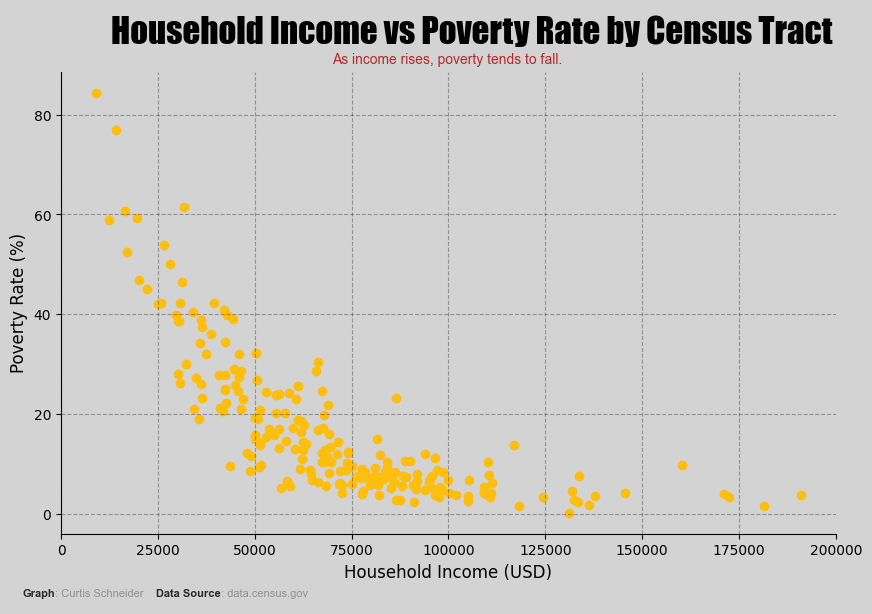

In [18]:
# Compare permit count vs poverty rate
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["HOUSEHOLD_INCOME_USD"], df_plot["POVERTY_RATE_PCT"])
plt.xlabel("Household Income (USD)")
plt.ylabel("Poverty Rate (%)")
#plt.title("Housing Need vs Poverty Rate by Census Tract")

# Title (added space for larger figure)
s = "Household Income vs Poverty Rate by Census Tract"
ax_text(x=13000, y=100, s=s, fontfamily='impact', size=25, ha="left")

# Additional subtitle
s = "As income rises, poverty tends to fall."
ax_text(x=70000, y=92.5, s=s, fontfamily='arial', size=10, ha="left", color="#AD0000", alpha=0.8)
plt.grid(alpha=0.3)

# Caption
s = "<Graph>: Curtis Schneider    <Data Source>: data.census.gov"
ax_text(
    x=-10000,
    y=-15,
    s=s,
    fontfamily='Arial',
    size=8,
    color='grey',
    ha="left",
    alpha=0.8,
    highlight_textprops=[
        {"weight": "bold", "color": "black"},
        {"weight": "bold", "color": "black"}
    ]
)

plt.grid(alpha=0.3)
apply_formatter()
plt.savefig(FIGURES_DIR / "income_poverty_scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

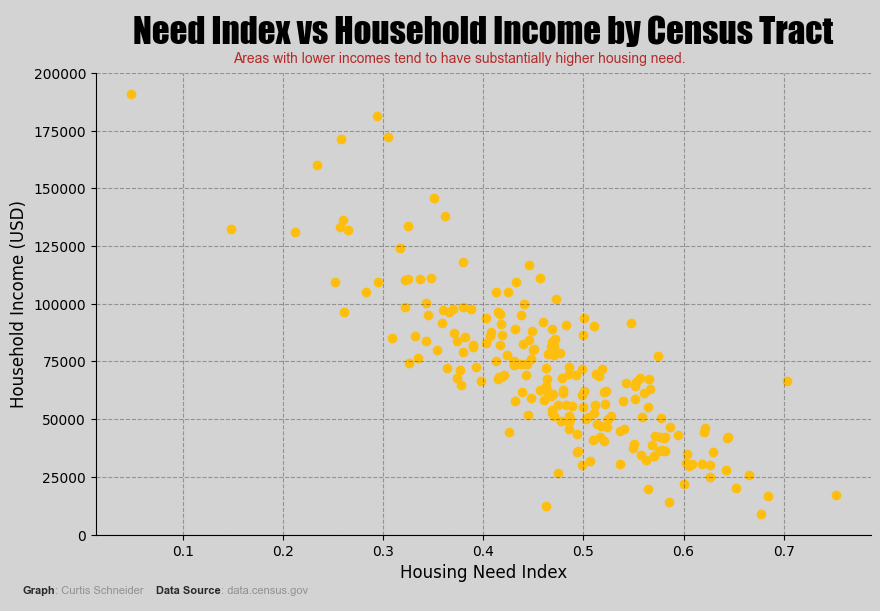

In [19]:
# Compare income vs need index
plt.figure(figsize=(10, 6))
plt.scatter(df_plot["NEED_INDEX"], df_plot["HOUSEHOLD_INCOME_USD"])
plt.xlabel("Housing Need Index")
plt.ylabel("Household Income (USD)")

# Title (added space for larger figure)
s = "Need Index vs Household Income by Census Tract"
ax_text(x=.05, y=225000, s=s, fontfamily='impact', size=25, ha="left")

# Additional subtitle
s = "Areas with lower incomes tend to have substantially higher housing need."
ax_text(x=.15, y=209000, s=s, fontfamily='arial', size=10, ha="left", color="#AD0000", alpha=0.8)
plt.grid(alpha=0.3)

# Caption
s = "<Graph>: Curtis Schneider    <Data Source>: data.census.gov"
ax_text(
    x=-0.06,
    y=-22000,
    s=s,
    fontfamily='Arial',
    size=8,
    color='grey',
    ha="left",
    alpha=0.8,
    highlight_textprops=[
        {"weight": "bold", "color": "black"},
        {"weight": "bold", "color": "black"}
    ]
)

plt.savefig(FIGURES_DIR / "need_income_scatter_plot.png", dpi=300, bbox_inches="tight")
plt.show()

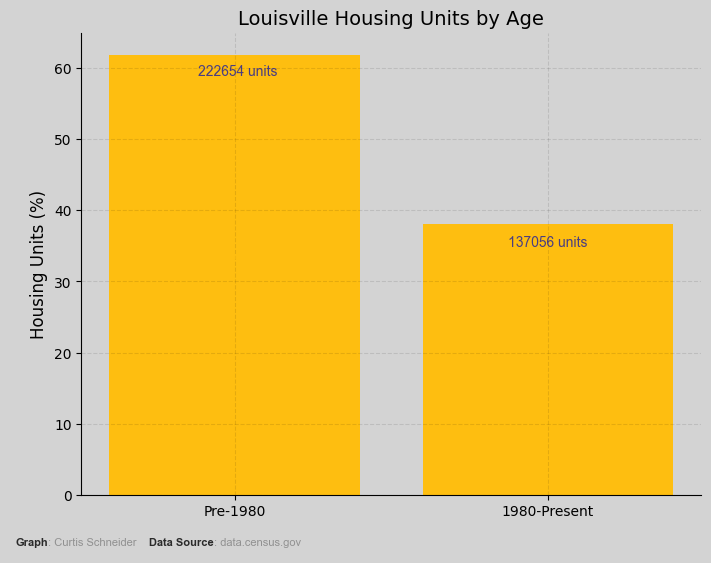

In [20]:
older_total = df_housing_age["OLDER_UNITS"].sum()
newer_total = df_housing_age["NEWER_UNITS"].sum()

total = older_total + newer_total

pct_older = older_total / total * 100
pct_newer = newer_total / total * 100

fig, ax = plt.subplots(figsize=(8,6))

ax.bar(
    ["Pre-1980", "1980-Present"],
    [pct_older, pct_newer]
)

ax.set_ylabel("Housing Units (%)")
ax.set_title("Louisville Housing Units by Age")

# Annotation arrow
ax.annotate(
    f"{older_total} units",
    xy=(0.05, 30),
    xytext=(0.01, 59),
    ha="center",
    fontsize=10,
    fontfamily='Arial',
    color="#1D1E9E",
    alpha=0.8,
    arrowprops=dict(
        arrowstyle="->",
        color="#FEBE10",
        lw=1.5,
        mutation_scale=15,
        connectionstyle="arc3,rad=0.3",
        alpha=0.6,
    )
)

# Annotation arrow
ax.annotate(
    f"{newer_total} units",
    xy=(1, 20),
    xytext=(1, 35),
    ha="center",
    fontsize=10,
    fontfamily='Arial',
    color="#1D1E9E",
    alpha=0.8,
    arrowprops=dict(
        arrowstyle="->",
        color="#FEBE10",
        lw=1.5,
        mutation_scale=15,
        connectionstyle="arc3,rad=0.3",
        alpha=0.6,
    )
)

# Caption
s = "<Graph>: Curtis Schneider    <Data Source>: data.census.gov"
ax_text(
    x=-0.7,
    y=-6,
    s=s,
    fontfamily='Arial',
    size=8,
    color='grey',
    ha="left",
    alpha=0.8,
    highlight_textprops=[
        {"weight": "bold", "color": "black"},
        {"weight": "bold", "color": "black"}
    ]
)

plt.savefig(FIGURES_DIR / "housing_age_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()